# Miniproyecto 1: ¡Bienvenido a tu nueva empresa!
#### **Curso:** Introducción a Minería de Datos y Machine Learning

---

**¡Bienvenido a AMAZOFF!**

Has sido seleccionado para unirte al equipo de E-commerce como Data Scientist Junior.

Después de integrarte al equipo, te han asignado tu primera misión:

> Trabajar con una base de datos antigua y descuidada que durante años nadie ha limpiado ni analizado.

Tu tarea es realizar un preprocessing de alta calidad para convertir estos datos en información valiosa que respalde
decisiones estratégicas.

La base de datos contiene información crucial sobre clientes, productos y transacciones, pero está plagada de
inconsistencias, datos faltantes y otros problemas que dificultan su uso.

El reto es mayor porque los resultados de tu análisis y las respuestas a las preguntas de negocio serán presentados
directamente al CEO de AMAZOFF.

Por lo tanto, debes aplicar tus conocimientos técnicos y comprender cómo tus hallazgos se alinean con las necesidades y
objetivos de la empresa.

**¿Estás listo para asumir tu nueva misión y demostrar que puedes hacer la diferencia en AMAZOFF?**

¡Es hora de empezar y transformar esos datos en información estratégica para el negocio!

# Pauta de Evaluación

Este MP1 está enfocado en responder preguntas de negocio relevantes para **AMAZOFF**.

### Preguntas de Negocio

1. (20 puntos) Tu líder de equipo necesitará explicar qué información contiene la base de datos al CEO de la empresa. ¿Podrías explicarle qué información contienen los datos?
2. (15 puntos) ¡Habemus data! Me dicen que los datos estaban muy sucios... ¿podrías corregir esto?
3. (20 puntos) ¡Me encantan los datos limpios! Pero es mucha data. ¿Podrías hacer algunos gráficos interesantes para el equipo de Marketing?
4. (20 puntos) Marketing ama los gráficos. Pero el CEO es una persona de números. Te pide un informe con 3 estadísticas MUY interesantes y NUEVAS de los datos.
5. (10 puntos) [ ERROR ] Detectamos que el rating va de 1-5, pero nuestros sistemas solo toleran ratings normalizados. ¿Nos puedes ayudar?
6. (15 puntos) El CEO está interesado en simplificar el análisis de datos complejos sin perder información crucial. ¿Puedes aplicar una técnica de reducción de dimensionalidad como PCA y explicar los resultados?

### Tener en consideración:

En caso de que el código esté bien, pero no se responda (usando celdas de texto) la pregunta de negocio (sección **Explicación**), **se asignará máximo la mitad de puntos** de esa pregunta.

> Al principio de la pregunta 3 tendrás la opción de descomentar un código (dando una explicación) que te permitirá utilizar la base de datos `output.csv` como `df`. Esto, en caso de que la pregunta 2 la encuentres muy difícil. Sin embargo, esto automáticamente te pondrá 0 puntos en la pregunta 2. Sin dar una explicación de por qué utilizarás esta opción, el tutor corrector puede comentar nuevamente la celda y queda `df` según lo realizado en la pregunta 2. ¡Ten cuidado!

El miniproyecto está diseñado para completar código. Suba el notebook solo con el código para responder la pregunta de negocio.

> # ¡NO OLVIDES GUARDAR Y SUBIR EL NOTEBOOK A LA PLATAFORMA CUANDO TERMINES! FORMATO .ipynb

# Preámbulo

In [405]:
# Machine Learning
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA

# General Data Science
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [406]:
# Esta configuración permite que los dataframes se muestren completos.
pd.set_option('display.max_columns', None)

# 1. Tu líder de equipo necesitará explicar qué información contiene la base de datos al CEO de la empresa. ¿Podrías explicarle qué información contienen los datos?

⁉️ **Consideración:** Los datos vienen divididos en tres bases de datos: `order`, `product` y `delivery`. Estas tienen en común algo que nos servirá para unirlas utilizando el método `join`. Une las tres bases de datos, mira qué datos hay, elimina las columnas que no utilizarás y reordenalas correctamente según `output.csv`. ¡No olvides explicar qué información contienen los datos!

ℹ️ **HINT:** ¿Para qué sirve el parámetro `r_suffix` del método `join`? ¿Qué información nos da `df.info()`?

📖 **Referencia Externa:** [Método `join`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.join.html).

---

✅ **Explicación:**

**Las 3 tablas que se listan a continuación corresponden respectivamente a: La tabla de órdenes (raw_ecommerce_order), que tiene los campos ciudad (city), método de pago (payment), número de vendedor (seller), fecha estimada de entrega (estimated_delivery), estado (state), clasificacion (rating), número de cliente (customer) y número de orden (order); La tabla de productos (raw_ecommerce_product), que tiene los campos precio, costo de envío (shipping), código de producto (product), número de cliente (customer), tipo de categoría (category), número de vendedor (seller) y número de orden (order); Y por último a la tabla de entregas (raw_ecommerce_delivery), con los campos número de orden (order), fecha de compra (purchased), fecha de entrega (delivered), costo de envío (shipping), fecha estimada de entrega (estimated_delivery) y código de producto (product). Las 3 tablas tienen en común el número de orden, siendo la tabla orden la que constituye la tabla cabecera de nuestros datos, la tabla product, la tabla de productos de la orden, que se relaciona con ésta a través del número de orden, y la tabla de entregas (delivery) que se relaciona con las 2 anteriores a través del número de orden y el código de producto, conteniendo además las fechas de compra, entrega y costo de entrega del producto de la orden.**

**El parámetro 'rsuffix' agrega el sufijo especificado, de lado derecho, de las columnas que se repiten en el join.
Mientras que el método 'df.info()' devuelve un resumen conciso de un dataframe incluyendo el tipo de índice, columnas, valores no nulos y uso de memoria.**

In [407]:
order = pd.read_csv('raw_ecommerce_order.csv', index_col=0, sep=',')
order.head(2)

,city,payment,seller,estimated_delivery,state,rating,customer,order
0,campinas,credit card,2.0,2018-01-30,SP,4.5,27313.0,27313.0
1,UNKNOWN,OTHER,7.0,2017-04-17 12:00:00,SP,1.0,47584.0,47584.0


In [408]:
product = pd.read_csv('raw_ecommerce_product.csv', index_col=0, sep=',')
product.head(2)

,precio,shipping,product,customer,category,seller,order
0,232.99,86.85,5.0,31453.0,toys,21.0,31453.0
1,383.5,2.94,5.0,55708.0,technology,10.0,55708.0


In [409]:
delivery = pd.read_csv('raw_ecommerce_delivery.csv', index_col=0, sep=',')
delivery.head(2)

,order,purchased,delivered,shipping,estimated_delivery,product
0,23487.0,2018-03-10 23:29:10,2018-03-23 15:58:23,133.52,NaN,6.0
1,11275.0,2018-01-19 13:39:35,2018-02-01 17:22:51,31.94,2018-02-15 12:00:00,7.0


In [410]:
df = order.join(product.set_index('order'), on='order', rsuffix='_product')
df = df.join(delivery.set_index("order"), on="order", rsuffix="_delivery")
df.head(3)

,city,payment,seller,estimated_delivery,state,rating,customer,order,precio,shipping,product,customer_product,category,seller_product,purchased,delivered,shipping_delivery,estimated_delivery_delivery,product_delivery
0,campinas,credit card,2.0,2018-01-30,SP,4.5,27313.0,27313.0,1094.04,58.02,8.0,27313.0,technology,2.0,2018-01-14 22:31:54,2018-01-22 16:03:40,58.02,2018-01-30,8.0
1,UNKNOWN,OTHER,7.0,2017-04-17 12:00:00,SP,1.0,47584.0,47584.0,76.6,55.54,0.0,47584.0,fashion,7.0,2017-03-25 15:33:43,VALORES EM FALTA,55.54,2017-04-17 12:00:00,0.0
1,UNKNOWN,OTHER,7.0,2017-04-17 12:00:00,SP,1.0,47584.0,47584.0,76.6,55.54,0.0,47584.0,fashion,7.0,2017-03-25 15:33:43,2017-03-30 17:47:57,55.54,2017-04-17 12:00:00,0.0


In [411]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7987 entries, 0 to 1800
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   city                         7614 non-null   object 
 1   payment                      7556 non-null   object 
 2   seller                       7987 non-null   float64
 3   estimated_delivery           7172 non-null   object 
 4   state                        7646 non-null   object 
 5   rating                       7586 non-null   object 
 6   customer                     7987 non-null   float64
 7   order                        7987 non-null   float64
 8   precio                       7719 non-null   object 
 9   shipping                     7662 non-null   object 
 10  product                      7987 non-null   float64
 11  customer_product             7987 non-null   float64
 12  category                     7571 non-null   object 
 13  seller_product         

In [412]:
sum(df.seller == df.seller_product)

7987

In [413]:
xy = df[["product","product_delivery"]].values
xy

array([[8., 8.],
       [0., 0.],
       [0., 0.],
       ...,
       [8., 8.],
       [8., 8.],
       [8., 8.]], shape=(7987, 2))

In [414]:
drop_columns = [
    "customer_product","seller_product","shipping_delivery","estimated_delivery_delivery","product_delivery"
]

df.drop(columns=drop_columns, inplace=True, errors='ignore')
df.head(2)

,city,payment,seller,estimated_delivery,state,rating,customer,order,precio,shipping,product,category,purchased,delivered
0,campinas,credit card,2.0,2018-01-30,SP,4.5,27313.0,27313.0,1094.04,58.02,8.0,technology,2018-01-14 22:31:54,2018-01-22 16:03:40
1,UNKNOWN,OTHER,7.0,2017-04-17 12:00:00,SP,1.0,47584.0,47584.0,76.6,55.54,0.0,fashion,2017-03-25 15:33:43,VALORES EM FALTA


In [415]:
correct_order = [
    "order","product","seller","customer","city","state","category","precio","shipping","payment","purchased","delivered","estimated_delivery","rating"
]

df = df[correct_order]
df.head(2)

,order,product,seller,customer,city,state,category,precio,shipping,payment,purchased,delivered,estimated_delivery,rating
0,27313.0,8.0,2.0,27313.0,campinas,SP,technology,1094.04,58.02,credit card,2018-01-14 22:31:54,2018-01-22 16:03:40,2018-01-30,4.5
1,47584.0,0.0,7.0,47584.0,UNKNOWN,SP,fashion,76.6,55.54,OTHER,2017-03-25 15:33:43,VALORES EM FALTA,2017-04-17 12:00:00,1.0


# 2. ¡Habemus data! Me dicen que los datos estaban muy sucios... ¿podrías corregir esto?

⁉️ **Consideración:** Deberás verificar datos faltantes, duplicados, tipos de datos incorrectos, etc. Completa el código en las celdas para realizar esto. Explica cada paso de la limpieza. Se te entregó una base de datos llamada `output.csv`. El resultado de tu limpieza debería intentar generar "exactamente" esta base de datos.

ℹ️ **HINT 1:** En el tratamiento de las fechas podría haber ligeras discrepancias con `output.csv`. No se descontará mientras sean ligeras.

ℹ️ **HINT 2:** En la columna *city*, el valor `unknown` no lo consideres dato faltante.

ℹ️ **HINT 3:** ¿Hay una hora fija para la estimación de las entregas?

📖 **Referencia Externa:** [Pandas Data Preprocessing](https://medium.com/@sujathamudadla1213/pandas-data-preprocessing-methods-e4fcee1de88b).

---

✅ **Explicación:**

***Se procede a la limpieza de los datos, rellenar datos faltantes y uniformar los datos y nombres de las columnas para que se asemeje al formato válido de salida 'output.csv'***

In [416]:
# Tu código debería producir un dataframe similar a `output`.
# No te preocupes si son ligeramente diferentes.
# Por ejemplo: Las fechas podrían ser ligeramente diferentes. Mismo día, diferentes segundos.
output = pd.read_csv('output.csv')
print(f'{output.shape[0]} filas y {output.shape[1]} columnas.')
output.head(2)

945 filas y 14 columnas.


,order,product,seller,customer,city,state,category,price,shipping,payment,purchased,delivered,estimated_delivery,rating
0,18,7,1,18,belo horizonte,mg,health,692.00,11.36,other,2017-03-07 19:19:19,2017-03-21 10:41:53,2017-03-08 16:38:19,4.0
1,134,9,13,134,unknown,sp,technology,97.07,13.25,credit card,2018-02-12 14:14:43,2018-02-16 10:22:35,2018-03-01 12:00:00,4.5


In [417]:
df.head(1)

,order,product,seller,customer,city,state,category,precio,shipping,payment,purchased,delivered,estimated_delivery,rating
0,27313.0,8.0,2.0,27313.0,campinas,SP,technology,1094.04,58.02,credit card,2018-01-14 22:31:54,2018-01-22 16:03:40,2018-01-30,4.5


In [418]:
# Renombra las columnas que tengan un nombre incorrecto.
# HINT: Utiliza el método rename con un diccionario.

df.rename(
    columns={'precio':'price'}, #Se reemplaza el texto "precio" de la cabecera, por "price"
    inplace=True,
    errors='ignore'
)

In [419]:
df.head(1)

,order,product,seller,customer,city,state,category,price,shipping,payment,purchased,delivered,estimated_delivery,rating
0,27313.0,8.0,2.0,27313.0,campinas,SP,technology,1094.04,58.02,credit card,2018-01-14 22:31:54,2018-01-22 16:03:40,2018-01-30,4.5


In [420]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7987 entries, 0 to 1800
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order               7987 non-null   float64
 1   product             7987 non-null   float64
 2   seller              7987 non-null   float64
 3   customer            7987 non-null   float64
 4   city                7614 non-null   object 
 5   state               7646 non-null   object 
 6   category            7571 non-null   object 
 7   price               7719 non-null   object 
 8   shipping            7662 non-null   object 
 9   payment             7556 non-null   object 
 10  purchased           7560 non-null   object 
 11  delivered           7632 non-null   object 
 12  estimated_delivery  7172 non-null   object 
 13  rating              7586 non-null   object 
dtypes: float64(4), object(10)
memory usage: 936.0+ KB


In [421]:
output.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 945 entries, 0 to 944
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order               945 non-null    int64  
 1   product             945 non-null    int64  
 2   seller              945 non-null    int64  
 3   customer            945 non-null    int64  
 4   city                945 non-null    object 
 5   state               945 non-null    object 
 6   category            945 non-null    object 
 7   price               945 non-null    float64
 8   shipping            945 non-null    float64
 9   payment             945 non-null    object 
 10  purchased           945 non-null    object 
 11  delivered           945 non-null    object 
 12  estimated_delivery  945 non-null    object 
 13  rating              945 non-null    float64
dtypes: float64(3), int64(4), object(7)
memory usage: 103.5+ KB


In [422]:
# Pasar todas las columnas de texto a minúsculas.
# HINT: Columnas tipo object son columnas de texto (string).

string_columns = [
    'city','state','category','price','shipping','payment'
    ,'purchased','delivered','estimated_delivery','rating'
]
for col in string_columns:
    df[col]=df[col].str.lower()

In [423]:
df.head(1)

,order,product,seller,customer,city,state,category,price,shipping,payment,purchased,delivered,estimated_delivery,rating
0,27313.0,8.0,2.0,27313.0,campinas,sp,technology,1094.04,58.02,credit card,2018-01-14 22:31:54,2018-01-22 16:03:40,2018-01-30,4.5


In [424]:
# Identificar datos faltantes diferentes y unificarlos. Unifícalos en np.nan.
# HINT: Utiliza df.value_counts("col") para identificar los valores faltantes en cada columna.
# HINT: Considera los diferentes valores faltantes. Hay al menos 5 diferentes.

print(f'Datos faltantes en el dataframe: {df.isnull().sum().sum()}')

MISSING_VALUES = [
    'no_info','nones','valores en falta','valores em falta','n/a','nan',''
]
df.replace(MISSING_VALUES, np.nan, inplace=True)

print(f'Datos faltantes unificados en el dataframe: {df.isnull().sum().sum()}')

Datos faltantes en el dataframe: 4152
Datos faltantes unificados en el dataframe: 11467


In [425]:
# Elimina datos duplicados.
# HINT: ¿Qué dato debería ser único en cada fila?

print(f'Filas en el dataframe: {df.shape[0]}')

df.drop_duplicates(['order'],inplace=True)

print(f'Filas en el dataframe (correcto=1000): {df.shape[0]}')

Filas en el dataframe: 7987
Filas en el dataframe (correcto=1000): 1000


In [426]:
df.price.sample(15)

112                      820.0
192                      42.79
951                       74.9
1176               199.1 reais
1340                      36.5
880                     172.99
881                     359.86
602                820.05 real
1467    231.27 real brasileiro
67                 475.0 reais
639                      35.09
742                   358.8 r$
139                    1299.99
1572                     113.1
915                      28.82
Name: price, dtype: object

In [427]:
# ¿Ves algo raro en los precios? ¿Qué deberías hacer con ellos?
# HINT: ¿Split? ¿Replace? ¿Lambda functions?
# HINT: Métodos de strings en pandas.

df.price = df.price.str.split().str[0] #Tomamos el 1er. valor antes del espacio en el monto precio
df.shipping = df.shipping.str.split().str[0] #Hacemos lo mismo con el costo de envio

In [428]:
df.price.sample(15)

1029    155.97
1049    330.99
299     109.82
190       79.8
149       42.2
953     236.52
1154    107.63
72      279.77
1370    252.99
64       50.21
324     789.89
1187     699.0
179        NaN
577     223.87
1037     148.5
Name: price, dtype: object

In [429]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 1799
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order               1000 non-null   float64
 1   product             1000 non-null   float64
 2   seller              1000 non-null   float64
 3   customer            1000 non-null   float64
 4   city                943 non-null    object 
 5   state               949 non-null    object 
 6   category            953 non-null    object 
 7   price               957 non-null    object 
 8   shipping            952 non-null    object 
 9   payment             936 non-null    object 
 10  purchased           939 non-null    object 
 11  delivered           950 non-null    object 
 12  estimated_delivery  802 non-null    object 
 13  rating              950 non-null    object 
dtypes: float64(4), object(10)
memory usage: 117.2+ KB


In [430]:
output.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 945 entries, 0 to 944
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order               945 non-null    int64  
 1   product             945 non-null    int64  
 2   seller              945 non-null    int64  
 3   customer            945 non-null    int64  
 4   city                945 non-null    object 
 5   state               945 non-null    object 
 6   category            945 non-null    object 
 7   price               945 non-null    float64
 8   shipping            945 non-null    float64
 9   payment             945 non-null    object 
 10  purchased           945 non-null    object 
 11  delivered           945 non-null    object 
 12  estimated_delivery  945 non-null    object 
 13  rating              945 non-null    float64
dtypes: float64(3), int64(4), object(7)
memory usage: 103.5+ KB


In [431]:
# Pasa los datos que deberían ser numéricos a numéricos.
# HINT: Hay datos númericos que son enteros (int) y otros que son decimales (float).
# HINT: Los enteros cuando son strings, pásalos primero a float y luego a int.

int_columns = ['order','product','seller','customer']
float_columns = ['price','shipping','rating']

df[int_columns] = df[int_columns].astype('float').astype('int')
df[float_columns] = df[float_columns].astype('float') #Hay datos str que no pueden convertirse en float

In [432]:
df.isnull().sum()

order                   0
product                 0
seller                  0
customer                0
city                   57
state                  51
category               47
price                  43
shipping               48
payment                64
purchased              61
delivered              50
estimated_delivery    198
rating                 50
dtype: int64

In [433]:
df

,order,product,seller,customer,city,state,category,price,shipping,payment,purchased,delivered,estimated_delivery,rating
0,27313,8,2,27313,campinas,sp,technology,1094.04,58.02,credit card,2018-01-14 22:31:54,2018-01-22 16:03:40,2018-01-30,4.5
1,47584,0,7,47584,unknown,sp,fashion,76.60,55.54,other,2017-03-25 15:33:43,NaN,2017-04-17 12:00:00,1.0
2,42432,16,10,42432,rio de janeiro,rj,sports,509.99,20.90,credit card,2018-02-14 11:54:55,2018-02-19 15:43:36,NaN,5.0
3,47325,13,4,47325,unknown,sp,health,24.10,7.52,credit card,2018-08-09 09:11:18,2018-08-13 21:03:57,2018-08-16 12:00:00,NaN
4,20502,6,22,20502,sao paulo,sp,NaN,509.99,NaN,credit card,2018-06-14 18:05:57,2018-06-20 15:34:52,NaN,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1757,41011,6,5,41011,unknown,sp,fashion,966.90,1.05,credit card,2018-05-26 16:54:05,2018-06-08 16:28:51,2018-06-28,3.0
1774,15682,9,15,15682,unknown,sp,fashion,509.99,17.38,credit card,2017-12-28 23:07:22,2018-01-08 15:05:37,2018-01-23 12:00:00,3.5
1789,14382,0,10,14382,unknown,sp,fashion,34.00,37.42,other,2017-11-15 16:48:17,2017-12-01 01:40:05,2017-12-06 12:00:00,1.0
1796,16530,4,2,16530,sao paulo,sp,sports,1663.00,9.18,credit card,2018-08-20 19:21:03,2018-08-30 19:36:44,2018-08-31 12:00:00,3.0


In [434]:
# ¡Fechas! ¿Qué deberíamos hacer con ellas?
# HINT: pd.to_datetime(). Considera el formato de las fechas.
# HINT: ¿Formato 'mixed'? ¿Qué es eso?

df.purchased = pd.to_datetime(df['purchased'],errors='coerce')
df.delivered = pd.to_datetime(df['delivered'],errors='coerce')

# ¿Ves algo raro en estimated_delivery?
# HINT: ¿Le falta algo a algunas fechas?
# HINT: ¿Podrías rellenar ese algo que falta? ¿Con qué valor? Investiga pd.Timedelta.

df.estimated_delivery = pd.to_datetime(df['estimated_delivery'],errors='coerce')
filter_zero = df.estimated_delivery.dt.hour == 0
df.loc[filter_zero, 'estimated_delivery'] += pd.Timedelta(0,'s')

df

,order,product,seller,customer,city,state,category,price,shipping,payment,purchased,delivered,estimated_delivery,rating
0,27313,8,2,27313,campinas,sp,technology,1094.04,58.02,credit card,2018-01-14 22:31:54,2018-01-22 16:03:40,2018-01-30,4.5
1,47584,0,7,47584,unknown,sp,fashion,76.60,55.54,other,2017-03-25 15:33:43,NaT,NaT,1.0
2,42432,16,10,42432,rio de janeiro,rj,sports,509.99,20.90,credit card,2018-02-14 11:54:55,2018-02-19 15:43:36,NaT,5.0
3,47325,13,4,47325,unknown,sp,health,24.10,7.52,credit card,2018-08-09 09:11:18,2018-08-13 21:03:57,NaT,NaN
4,20502,6,22,20502,sao paulo,sp,NaN,509.99,NaN,credit card,2018-06-14 18:05:57,2018-06-20 15:34:52,NaT,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1757,41011,6,5,41011,unknown,sp,fashion,966.90,1.05,credit card,2018-05-26 16:54:05,2018-06-08 16:28:51,2018-06-28,3.0
1774,15682,9,15,15682,unknown,sp,fashion,509.99,17.38,credit card,2017-12-28 23:07:22,2018-01-08 15:05:37,NaT,3.5
1789,14382,0,10,14382,unknown,sp,fashion,34.00,37.42,other,2017-11-15 16:48:17,2017-12-01 01:40:05,NaT,1.0
1796,16530,4,2,16530,sao paulo,sp,sports,1663.00,9.18,credit card,2018-08-20 19:21:03,2018-08-30 19:36:44,NaT,3.0


In [435]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 1799
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order               1000 non-null   int64         
 1   product             1000 non-null   int64         
 2   seller              1000 non-null   int64         
 3   customer            1000 non-null   int64         
 4   city                943 non-null    object        
 5   state               949 non-null    object        
 6   category            953 non-null    object        
 7   price               957 non-null    float64       
 8   shipping            952 non-null    float64       
 9   payment             936 non-null    object        
 10  purchased           939 non-null    datetime64[ns]
 11  delivered           950 non-null    datetime64[ns]
 12  estimated_delivery  278 non-null    datetime64[ns]
 13  rating              950 non-null    float64       
dt

In [436]:
df.isnull().sum()

order                   0
product                 0
seller                  0
customer                0
city                   57
state                  51
category               47
price                  43
shipping               48
payment                64
purchased              61
delivered              50
estimated_delivery    722
rating                 50
dtype: int64

In [437]:
# Hay una columna muy especial. ¿Cuál es? ¿Qué deberíamos hacer con los datos faltantes?
# HINT: Hay una columna que si no tiene datos, no nos sirve de nada.

#df.dropna(
#     axis=0 #Filas
#    ,subset=['estimated_delivery'] #'estimated_delivery' contiene demasiados datos nulos
#    ,inplace=True #modificar df, no crear uno nuevo
#)

#Se decide no eliminar las filas ya que quedarían muy pocos datos
df

,order,product,seller,customer,city,state,category,price,shipping,payment,purchased,delivered,estimated_delivery,rating
0,27313,8,2,27313,campinas,sp,technology,1094.04,58.02,credit card,2018-01-14 22:31:54,2018-01-22 16:03:40,2018-01-30,4.5
1,47584,0,7,47584,unknown,sp,fashion,76.60,55.54,other,2017-03-25 15:33:43,NaT,NaT,1.0
2,42432,16,10,42432,rio de janeiro,rj,sports,509.99,20.90,credit card,2018-02-14 11:54:55,2018-02-19 15:43:36,NaT,5.0
3,47325,13,4,47325,unknown,sp,health,24.10,7.52,credit card,2018-08-09 09:11:18,2018-08-13 21:03:57,NaT,NaN
4,20502,6,22,20502,sao paulo,sp,NaN,509.99,NaN,credit card,2018-06-14 18:05:57,2018-06-20 15:34:52,NaT,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1757,41011,6,5,41011,unknown,sp,fashion,966.90,1.05,credit card,2018-05-26 16:54:05,2018-06-08 16:28:51,2018-06-28,3.0
1774,15682,9,15,15682,unknown,sp,fashion,509.99,17.38,credit card,2017-12-28 23:07:22,2018-01-08 15:05:37,NaT,3.5
1789,14382,0,10,14382,unknown,sp,fashion,34.00,37.42,other,2017-11-15 16:48:17,2017-12-01 01:40:05,NaT,1.0
1796,16530,4,2,16530,sao paulo,sp,sports,1663.00,9.18,credit card,2018-08-20 19:21:03,2018-08-30 19:36:44,NaT,3.0


In [438]:
# Rellena los datos faltantes. Cada columna tiene un método diferente.
# Hay columnas donde no es posible rellenar los datos faltantes. ¿Las borramos?
# HINT: Habrá columnas donde no importa si hay datos faltantes. ¿Cuáles son?

# State: ¿El estado más común? ¿La moda?
# HINT: La moda es el valor más común en una columna. Utiliza el método mode.

df.state = df.state.fillna(0) #Si no viene el estado, se coloca un '0'

# City: ¿La ciudad más común? ¿La ciudad puede estar relacionada con el estado?
# HINT: La función map de pandas sirve para reemplazar valores con un diccionario.

replace_city = {
    'sp': 'sao paulo',
    'rj': 'rio de janeiro'
}
df.city = df.city.fillna(df.state.map(replace_city))
df.city = df.city.fillna(0) #Para el resto se coloca '0'

# ¿Qué otras columnas se pueden rellenar?
# HINT CATEGORY: ¿Cuál es la categoría más común?
# HINT PRICE: ¿Cuál es el precio promedio?
# HINT SHIPPING: ¿Cuál es el precio promedio del envío?
# HINT PAYMENT: ¿Cuál es el método de pago más común?

#Para los nulos se coloca '0':
df.category = df.category.fillna(0) # No se hacen mas reemplazos para evitar perdida de informacion
df.price = df.price.fillna(0) # No se hacen mas reemplazos para evitar perdida de informacion
df.shipping = df.shipping.fillna(0) # No se hacen mas reemplazos para evitar perdida de informacion
df.payment = df.payment.fillna(0) # No se hacen mas reemplazos para evitar perdida de informacion

# ¡Fechas! ¿Qué deberíamos hacer con ellas?
# HINT PURCHASED: En promedio, ¿cuánto tiempo pasa entre que se compra y se envía?
# HINT DELIVERED: En promedio, ¿cuánto tiempo pasa entre que se envía y se entrega?
# HINT ESTIMATED_DELIVERY: En promedio, ¿cuánto tiempo pasa entre que se envía y se estima que se entrega?

#mean_purchased_to_delivered = (df.delivered-df.purchased).mean()
#mean_purchased_to_estimated = (df.delivered-df.delivered).mean()
#mean_delivered_to_estimated = (df.estimated_delivery-df.delivered).mean()

# Se rellena con todas las combinaciones posibles.

#df.purchased = df.purchased.fillna(df.delivered-mean_purchased_to_delivered)          
#df.purchased = df.purchased.fillna(df.estimated_delivery-mean_purchased_to_estimated) 
df.purchased = df.purchased.fillna(pd.to_datetime('1900-01-01')) # No se hacen mas reemplazos para evitar perdida de informacion

df.delivered = df.delivered.fillna(pd.to_datetime('1900-01-01'))
#df.delivered = # No se hacen reemplazos para evitar perdida de informacion

df.estimated_delivery = df.estimated_delivery.fillna(pd.to_datetime('1900-01-01'))
#df.estimated_delivery = # No se hacen reemplazos para evitar perdida de informacion

df

,order,product,seller,customer,city,state,category,price,shipping,payment,purchased,delivered,estimated_delivery,rating
0,27313,8,2,27313,campinas,sp,technology,1094.04,58.02,credit card,2018-01-14 22:31:54,2018-01-22 16:03:40,2018-01-30,4.5
1,47584,0,7,47584,unknown,sp,fashion,76.60,55.54,other,2017-03-25 15:33:43,1900-01-01 00:00:00,1900-01-01,1.0
2,42432,16,10,42432,rio de janeiro,rj,sports,509.99,20.90,credit card,2018-02-14 11:54:55,2018-02-19 15:43:36,1900-01-01,5.0
3,47325,13,4,47325,unknown,sp,health,24.10,7.52,credit card,2018-08-09 09:11:18,2018-08-13 21:03:57,1900-01-01,NaN
4,20502,6,22,20502,sao paulo,sp,0,509.99,0.00,credit card,2018-06-14 18:05:57,2018-06-20 15:34:52,1900-01-01,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1757,41011,6,5,41011,unknown,sp,fashion,966.90,1.05,credit card,2018-05-26 16:54:05,2018-06-08 16:28:51,2018-06-28,3.0
1774,15682,9,15,15682,unknown,sp,fashion,509.99,17.38,credit card,2017-12-28 23:07:22,2018-01-08 15:05:37,1900-01-01,3.5
1789,14382,0,10,14382,unknown,sp,fashion,34.00,37.42,other,2017-11-15 16:48:17,2017-12-01 01:40:05,1900-01-01,1.0
1796,16530,4,2,16530,sao paulo,sp,sports,1663.00,9.18,credit card,2018-08-20 19:21:03,2018-08-30 19:36:44,1900-01-01,3.0


In [439]:
# ¡No modificar esta celda!
# Al final de la limpieza, deberías tener 0 datos faltantes y 945 filas.

print(f'Datos faltantes en el dataframe: {df.isnull().sum().sum()}')

# Borramos datos faltantes, reordenamos y reseteamos el índice.
df.dropna(inplace=True)
df.sort_values('order', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'¡Limpieza de datos finalizada! Tiene {df.shape[0]} filas y {df.shape[1]} columnas.')
df.head(3)

Datos faltantes en el dataframe: 50
¡Limpieza de datos finalizada! Tiene 950 filas y 14 columnas.


,order,product,seller,customer,city,state,category,price,shipping,payment,purchased,delivered,estimated_delivery,rating
0,18,7,1,18,belo horizonte,mg,health,692.00,11.36,other,2017-03-07 19:19:19,2017-03-21 10:41:53,1900-01-01,4.0
1,134,9,13,134,unknown,sp,technology,97.07,13.25,credit card,2018-02-12 14:14:43,2018-02-16 10:22:35,1900-01-01,4.5
2,157,12,10,157,sao paulo,sp,health,95.03,39.84,credit card,2018-04-08 14:03:56,2018-04-10 20:34:41,1900-01-01,2.5


In [440]:
# ¡No olvides que deberías tener un dataframe similar a `output`!
print(f'{output.shape[0]} filas y {output.shape[1]} columnas.')
output.head(3)

945 filas y 14 columnas.


,order,product,seller,customer,city,state,category,price,shipping,payment,purchased,delivered,estimated_delivery,rating
0,18,7,1,18,belo horizonte,mg,health,692.00,11.36,other,2017-03-07 19:19:19,2017-03-21 10:41:53,2017-03-08 16:38:19,4.0
1,134,9,13,134,unknown,sp,technology,97.07,13.25,credit card,2018-02-12 14:14:43,2018-02-16 10:22:35,2018-03-01 12:00:00,4.5
2,157,12,10,157,sao paulo,sp,health,95.03,39.84,credit card,2018-04-08 14:03:56,2018-04-10 20:34:41,2018-04-09 11:22:56,2.5


# 3. ¡Me encantan los datos limpios! Pero es mucha data. ¿Podrías hacer algunos gráficos interesantes para el equipo de Marketing?

⁉️ **Consideración:** Debes de pensar en tres gráficos DIFERENTES que respondan preguntas de negocio importantes para **AMAZOFF** según los datos disponibles. ¡No olvides que dato e información no son lo mismo! Debes explicar por qué hiciste cada gráfico y qué información valiosa para el negocio lograste sacar.

ℹ️ **HINT 1:** ¿Sabías que puedes hacer gráficos muy lindos utilizando `sns` (Seaborn)? Matplotlib y Seaborn te servirán para hacer gráficos sofisticados. No olvides que un gŕafico debe incluir títulos, leyenda, etc.

ℹ️ **HINT 2:** Gráficos diferentes en general significa que puedes aprender cosas totalmente diferentes entre los gráficos. Dos gráficos pueden ser diferentes y utililizar la misma función, pero intenta utilizar 3 métodos distintos.

📖 **Referencia Externa:** [Seaborn Examples](https://medium.com/geekculture/8-best-seaborn-visualizations-20143a4b3b2f), [Seaborn Basic Tutorial](https://medium.com/@armantunga/data-visualization-made-easy-seaborn-with-python-a-beginners-guide-e24a9ea9e599), [Matplotlib Cheatsheets](https://matplotlib.org/cheatsheets/).

---

✅ **Explicación:**

- **Gráfico 1 (Gráfico de dispersión):** Se utiliza un gráfico de dispersión para mostrar la conexión entre dos variables. Muestra un conjunto de puntos de datos, donde cada punto representa el valor de dos variables. Los gráficos de dispersión se utilizan con frecuencia para visualizar patrones y correlaciones en los datos. Son los más adecuados para los datos numéricos continuos **(Fuente: Visualización de datos Hecho Fácil, "Seaborn with Python: A Beginner’s Guide")**.
- **Gráfico 2 (Gráfico de línea):** Un gráfico de línea se utiliza comúnmente para mostrar tendencias a lo largo del tiempo o para mostrar datos continuos. Los gráficos de línea son las más adecuadas para visualizar datos que cambian con el tiempo o en diferentes categorías **(Fuente: Visualización de datos Hecho Fácil, "Seaborn with Python: A Beginner’s Guide")**.
- **Gráfico 3 (Gráfico de barras):** Un gráfico de barra se utiliza para mostrar la frecuencia o proporción de datos categóricos. Muestra los datos como barras rectangulares, donde la longitud de cada barra representa el valor de una categoría. Los gráficos de barras son los más adecuados para visualizar datos categóricos discretos **(Fuente: Visualización de datos Hecho Fácil, "Seaborn with Python: A Beginner’s Guide")**.

In [441]:
##Gráfico 1 (verificacion gráfica de datos obtenidos):
## Crear una "parcela" de dispersión usando Seaborn:
#sns.scatterplot(x="seller", y="order", data=df) #Relacion entre el vendedor y las ordenes procesadas 
## Guardar figura:
#plt.savefig("scatterplot.png")
## Mostrar la trama:
#plt.show()

In [442]:
##Gráfico 2 (verificacion gráfica de datos obtenidos):
## Establece el estilo de la trama:
#sns.set_style("whitegrid")
## Crea una trama de línea usando Seaborn:
#sns.lineplot(x="product", y="order", data=df, marker="o", color="purple") #Relacion entre el numero de producto y las ordenes procesadas
## Establezca el título de la trama y etiquetas de eje:
#plt.title("Ordenes por producto")
#plt.xlabel("Producto")
#plt.ylabel("Ordenes")
## Rotar las etiquetas de eje x 45 grados para hacerlos más legibles:
#plt.xticks(rotation=45)
## Retire la parte superior y la derecha de las espinas:
#sns.despine()
## Muestre la trama:
#plt.show()

In [443]:
##Gráfico 3 (verificacion gráfica de datos obtenidos):
## Filtrar los datos para incluir únicamente a los sobrevivientes:
#lproductosvendidos = df[df["delivered"] != pd.to_datetime('1900-01-01')]["product"].value_counts() #Lista de productos entregados
## Crear un grafico de barra usando Seaborn:
#sns.barplot(x=lproductosvendidos.index, y=lproductosvendidos.values)
## Establezca el título de la trama y etiquetas de eje:
#plt.title("Productos vendidos")
#plt.xlabel("Productos")
#plt.ylabel("Cantidad")
## Guardar figura:
#plt.savefig("bar-plot.png")
## Mostrar la trama:
#plt.show()

In [444]:
# ¡Lee con cuidado la pauta de evaluación! ¿Tuviste problemas con la limpieza de datos?

########################################################################################################################

# Si descomentas los siguientes códigos, tu pregunta 2 tendrá 0 puntos.
# ¡No olvides que debes explicar por qué decidiste descomentar este código!

    # Explicación: SE DECIDE MANTENER LOS DATOS OBTENIDOS YA QUE SE PARECEN MUCHO A OUTPUT

# Reemplazar df por output en caso de que tuviste problemas con la limpieza de datos (pregunta 2 con 0 puntos).

#df = pd.read_csv('output.csv')
#df.purchased = pd.to_datetime(df.purchased)
#df.delivered = pd.to_datetime(df.delivered)
#df.estimated_delivery = pd.to_datetime(df.estimated_delivery)
#df.head(3)
df.to_csv('myout1.csv') #Graba trama para comparación

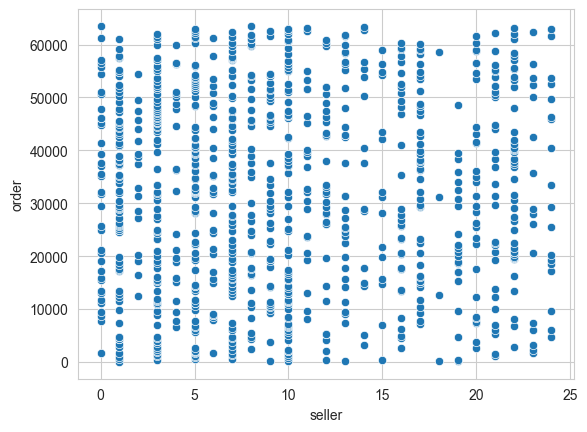

In [445]:
# Gráfico 1: GRÁFICO DE DISPERSIÓN DE ORDENES PROCESADAS POR VENDEDOR.

# Crear una "parcela" de dispersión usando Seaborn:
sns.scatterplot(x="seller", y="order", data=df) #Relacion entre el vendedor y las ordenes procesadas 
# Guardar figura:
plt.savefig("scatterplot.png")
# Mostrar la trama:
plt.show()

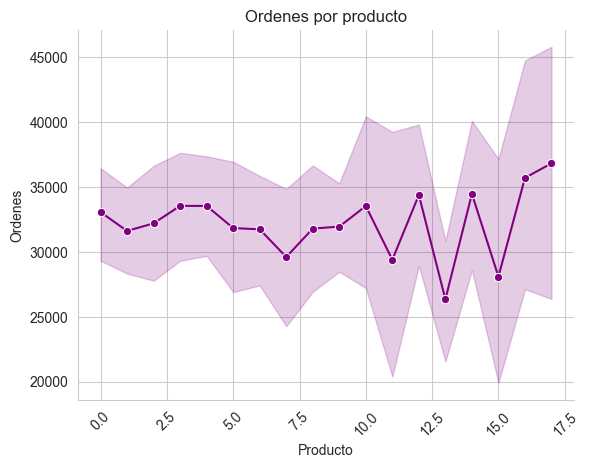

In [446]:
# Gráfico 2: GRÁFICO DE LINEA DE NÚMERO DE ORDENES POR NÚMERO DE PRODUCTO.

# Establece el estilo de la trama:
sns.set_style("whitegrid")
# Crea una trama de línea usando Seaborn:
sns.lineplot(x="product", y="order", data=df, marker="o", color="purple") #Relacion entre el numero de producto y las ordenes procesadas
# Establezca el título de la trama y etiquetas de eje:
plt.title("Ordenes por producto")
plt.xlabel("Producto")
plt.ylabel("Ordenes")
# Rotar las etiquetas de eje x 45 grados para hacerlos más legibles:
plt.xticks(rotation=45)
# Retire la parte superior y la derecha de las espinas:
sns.despine()
# Muestre la trama:
plt.show()

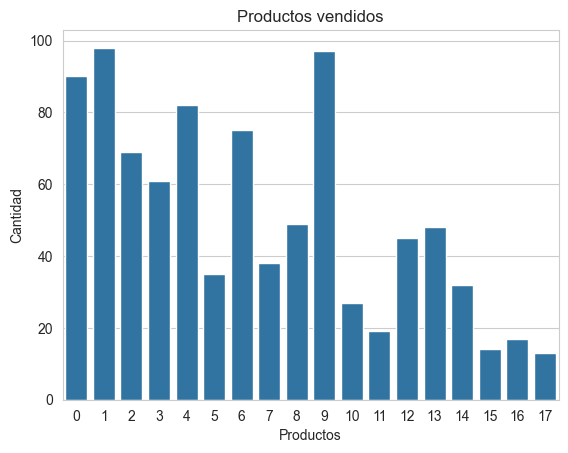

In [447]:
# Gráfico 3: GRÁFICO DE BARRAS DE NÚMERO DE PRODUCTOS VENDIDOS POR PRODUCTO.

# Filtrar los datos para incluir únicamente a los sobrevivientes:
lproductosvendidos = df[df["delivered"] != pd.to_datetime('1900-01-01')]["product"].value_counts() #Lista de productos entregados
# Crear un grafico de barra usando Seaborn:
sns.barplot(x=lproductosvendidos.index, y=lproductosvendidos.values)
# Establezca el título de la trama y etiquetas de eje:
plt.title("Productos vendidos")
plt.xlabel("Productos")
plt.ylabel("Cantidad")
# Guardar figura:
plt.savefig("bar-plot.png")
# Mostrar la trama:
plt.show()

# 4. Marketing ama los gráficos. Pero el CEO es una persona de números. Te pide un informe con 3 estadísticas MUY interesantes y NUEVAS de los datos.

⁉️ **Consideración:** Debes de generar tres códigos, cada uno debe generar estadísticas (ejemplo: números, DataFrame, Series, etc.) que aporten información valiosa para **AMAZOFF**. ¡La información debe ser diferente a la que aportan los gráficos de la pregunta 3. Para que cuente como estadística interesante, no puede ser simplemente calcular un promedio o una desviación. ¡Debes de modificar los datos, filtrarlos, agruparlos, u otros!

ℹ️ **HINT 1:** Funciones como `groupby`, `rolling`, `resample`, calcular estadísticas con filtros, por grupos, etc... son métodos que generan estadísticas más interesantes.

ℹ️ **HINT 2:** La forma más fácil es mezclar métodos avanzados con cálculos descriptivos básicos (ejemplo: media, mediana, moda, desviación, percentiles, etc.).

ℹ️ **HINT 3:** ¡Explica cómo tu estadística puede ser útil para **AMAZOFF**!

📖 **Referencia Externa:** [Pandas Data Analysis](https://medium.com/@anshulika12/deep-dive-into-pandas-and-numpy-advanced-data-analysis-techniques-3b381ad31785).

---

✅ **Explicación:**

- **Estadística 1:** Promedio de ventas efectivamente entregadas por producto
- **Estadística 2:** Ciudad con máximo de ventas
- **Estadística 3:** Vendedor que menos ventas efectivas realizó

In [448]:
# Estadística 1: PROMEDIO DE VENTAS EFECTIVAMENTE ENTREGADAS POR PRODUCTO

lproductosvendidos = df[df["delivered"] != pd.to_datetime('1900-01-01')]["product"].value_counts() #Lista de productos entregados

navgprod = np.average(lproductosvendidos) #Promedio de productos entregados.

print("El promedio de ventas efectivamente entregadas por producto es de: {}".format(navgprod))

El promedio de ventas efectivamente entregadas por producto es de: 50.5


In [449]:
# Estadística 2: CIUDAD CON MÁXIMO DE VENTAS

lventasporciudad = df[df["delivered"] != pd.to_datetime('1900-01-01')]["city"].value_counts() #Lista de ventas efectivas por ciudad

sciudad = lventasporciudad[lventasporciudad.values == np.max(lventasporciudad)].index[0] #Ciudad donde se vendieron mas productos
nventas = lventasporciudad[lventasporciudad.values == np.max(lventasporciudad)].values[0] #Numero de ventas en esa ciudad

print("La ciudad donde se vendió más es '{}', con {} ventas".format(sciudad,nventas))

La ciudad donde se vendió más es 'unknown', con 476 ventas


In [450]:
# Estadística 3: VENDEDOR QUE MENOS VENTAS EFECTIVAS REALIZÓ

lventasporvendedor = df[df["delivered"] != pd.to_datetime('1900-01-01')]["seller"].value_counts() #Ventas efectivas por vendedor

numvendedor = lventasporvendedor[lventasporvendedor.values == np.min(lventasporvendedor)].index[0] #Vendedor N°
numventas = lventasporvendedor[lventasporvendedor.values == np.min(lventasporvendedor)].values[0] #Numero de ventas de ese vendedor

print("El vendedor que menos ventas efectivas realizó es el vendedor N°{}, con {} ventas".format(numvendedor,numventas))

El vendedor que menos ventas efectivas realizó es el vendedor N°18, con 3 ventas


# 5. [ ERROR ] Detectamos que el rating va de 1-5, pero nuestros sistemas solo toleran ratings normalizados. ¿Nos puedes ayudar?

⁉️ **Consideración:** En ejercicio deberás Normalizar y Estandarizar. Pero sobre todo, se busca profundizar sobre cuándo se utilizaría cada medida. Por lo que debes de pensar en ejemplos de negocios donde aplicarías una técnica o la otra.

ℹ️ **HINT:** Imagina diferentes escenarios donde la escala para el negocio podría ser relevante. Enfócate en las características del negocio, no en un tema técnico (mal enfoque: el sistema interno lo requiere).

📖 **Referencia Externa:** [Normalization](https://www.geeksforgeeks.org/data-normalization-with-pandas/).

---

✅ **Explicación:**

- **¿En qué casos utilizarías normalización?** En caso de datos muy dispersos, ocuparía algún método de regresión lineal o no lineal para tener datos más comprensibles y analizables.
- **¿En qué casos utilizarías estandarización?** En caso de tener un dato proveniente de varias tablas transaccionales o fuentes distintas, se busca un método que permita transformar tal dato a un criterio común. 
- **¿Qué otra columa del DataFrame crees que se podría normalizar o estandarizar?** Los valores monetarios, como el precio (price), debieran normalizarse eliminando datos extremos o fuera de rango y previamente estandarizarse a una moneda común, en caso de tener unidades monetarias distintas.

In [451]:
# Normalización

minmax = MinMaxScaler()
df['minmax_rating'] = minmax.fit_transform(df[['rating']])

df.head(3)

,order,product,seller,customer,city,state,category,price,shipping,payment,purchased,delivered,estimated_delivery,rating,minmax_rating
0,18,7,1,18,belo horizonte,mg,health,692.00,11.36,other,2017-03-07 19:19:19,2017-03-21 10:41:53,1900-01-01,4.0,0.750
1,134,9,13,134,unknown,sp,technology,97.07,13.25,credit card,2018-02-12 14:14:43,2018-02-16 10:22:35,1900-01-01,4.5,0.875
2,157,12,10,157,sao paulo,sp,health,95.03,39.84,credit card,2018-04-08 14:03:56,2018-04-10 20:34:41,1900-01-01,2.5,0.375


In [452]:
# Estandarización

std = StandardScaler()
df['std_rating'] = std.fit_transform(df[['rating']])

df.head(3)

,order,product,seller,customer,city,state,category,price,shipping,payment,purchased,delivered,estimated_delivery,rating,minmax_rating,std_rating
0,18,7,1,18,belo horizonte,mg,health,692.00,11.36,other,2017-03-07 19:19:19,2017-03-21 10:41:53,1900-01-01,4.0,0.750,0.982063
1,134,9,13,134,unknown,sp,technology,97.07,13.25,credit card,2018-02-12 14:14:43,2018-02-16 10:22:35,1900-01-01,4.5,0.875,1.348361
2,157,12,10,157,sao paulo,sp,health,95.03,39.84,credit card,2018-04-08 14:03:56,2018-04-10 20:34:41,1900-01-01,2.5,0.375,-0.116830


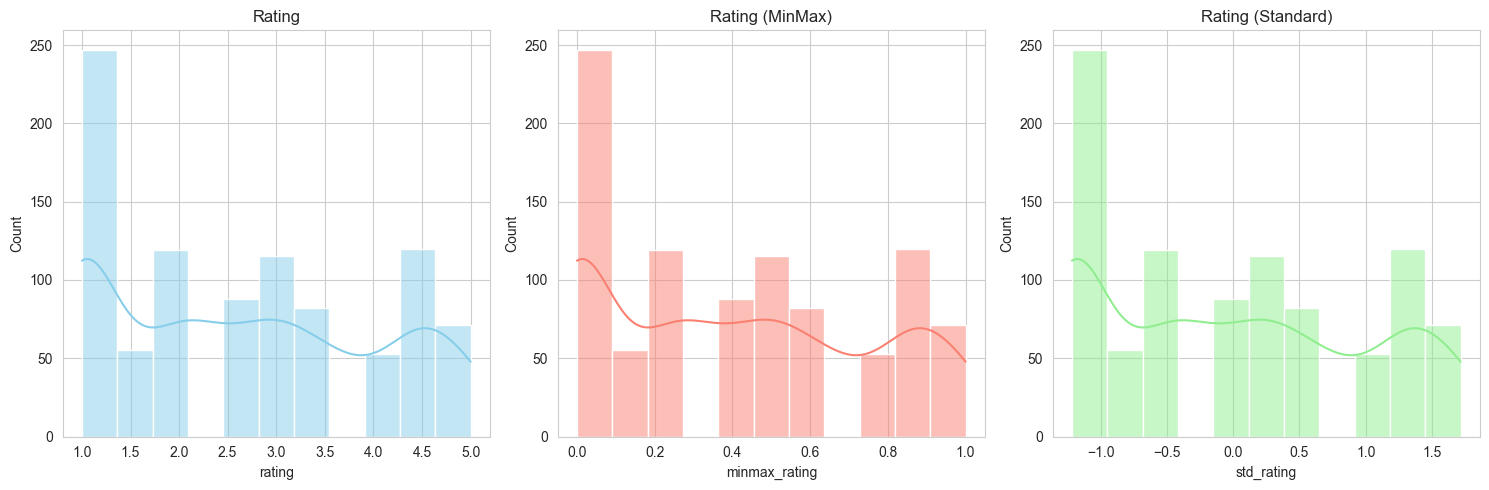

In [453]:
# ¡No modificar esta celda! Gráficos de Ratings normalizados. Fíjate en el eje x.

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df.rating, kde=True, ax=ax[0], color='skyblue')
sns.histplot(df.minmax_rating, kde=True, ax=ax[1], color='salmon')
sns.histplot(df.std_rating, kde=True, ax=ax[2], color='lightgreen')

ax[0].set_title('Rating')
ax[1].set_title('Rating (MinMax)')
ax[2].set_title('Rating (Standard)')

plt.tight_layout()
plt.show()

# 6. El CEO está interesado en simplificar el análisis de datos complejos sin perder información crucial. ¿Puedes aplicar una técnica de reducción de dimensionalidad como PCA y explicar los resultados?

⁉️ **Consideración:** Primero, crea nuevas features. Utilizarás esas y otra features para hacer una reducción de dimensionalidad. No olvides escalar tus datos antes. La parte compleja de este ejercicio es explicar tus hallazgos en el gráfico de PCA con 2 componentes.

ℹ️ **HINT:** ¿Ves una tendencia en los colores del gráfico? ¿Grupos?

📖 **Referencia Externa:** [Python PCA](https://www.geeksforgeeks.org/implementing-pca-in-python-with-scikit-learn/).

---

✅ **Explicación:**

[ AGREGA TU RESPUESTA ACÁ ]

In [454]:
# ¡No modificar esta celda! Agregaremos más datos al dataframe.

# Hora de compra y entrega.
df['purchase_hour'] = df.purchased.dt.hour
df['delivery_hour'] = df.delivered.dt.hour

# Día de la semana de compra y entrega.
df['purchase_weekday'] = df.purchased.dt.weekday
df['delivery_weekday'] = df.delivered.dt.weekday

# Precio del producto versus precio del envío.
df['price_shipping_rate'] = df.price/(df.price+df.shipping)

# Precio y envío ajustados por los percentiles 20 y 80.
df['pricing_clipped'] = df.price.clip(df.price.quantile(0.2), df.price.quantile(0.8))
df['shipping_clipped'] = df.shipping.clip(df.shipping.quantile(0.2), df.shipping.quantile(0.8))

df.head(1)

,order,product,seller,customer,city,state,category,price,shipping,payment,purchased,delivered,estimated_delivery,rating,minmax_rating,std_rating,purchase_hour,delivery_hour,purchase_weekday,delivery_weekday,price_shipping_rate,pricing_clipped,shipping_clipped
0,18,7,1,18,belo horizonte,mg,health,692.0,11.36,other,2017-03-07 19:19:19,2017-03-21 10:41:53,1900-01-01,4.0,0.75,0.982063,19,10,1,1,0.983849,491.91,13.92


In [455]:
# ¿Qué columnas deberíamos considerar para un análisis de componentes principales?

cols_pca = [
    'seller'#,'city','price'
]

# ¿Qué método de escalamiento deberíamos utilizar?

scaler = StandardScaler()
df_scaled = scaler.fit(df[cols_pca])
#df_scaled = pd.DataFrame(df_scaled, columns=cols_pca)
#df_scaled.head(3)

In [ ]:
# Genera un modelo de PCA con 2 componentes y ajusta el modelo a los datos escalados.

pca = # [ AGREGA TU CÓDIGO AQUÍ ]
df[['component_1', 'component_2']] = pca.fit_transform# [ AGREGA TU CÓDIGO AQUÍ ]
df.head(3)

In [ ]:
# Gráfico de componentes principales según rating. ¿Qué puedes inferir de este gráfico?
# HINT: Utiliza el parámetro hue para colorear los puntos según el rating.

sns.scatterplot(
    data=df,
    x=# [ AGREGA TU CÓDIGO AQUÍ ]
    y=# [ AGREGA TU CÓDIGO AQUÍ ]
    hue=# [ AGREGA TU CÓDIGO AQUÍ ]
    palette='RdYlBu',
    legend='full'
)

plt.title('Componentes Principales')
plt.show()

In [ ]:
# ¿Cuánta varianza explica cada componente?

print(f'Varianza explicada por cada componente: {pca.explained_variance_ratio_}')
print(f'Varianza explicada total: {# [ AGREGA TU CÓDIGO AQUÍ ]

> # ¡NO OLVIDES GUARDAR Y SUBIR EL NOTEBOOK A LA PLATAFORMA CUANDO TERMINES! FORMATO .ipynb